In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel File
xls_yt = pd.ExcelFile('/content/drive/MyDrive/youtubeSpamCollection.xlsx')
df_yt_list = [pd.read_excel(xls_yt, sheet_name=s) for s in xls_yt.sheet_names]
df_yt = pd.concat(df_yt_list, ignore_index=True)

# Display first 5 rows
df_yt.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^...,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .ï»¿,1


In [3]:
print("=== YOUTUBE SPAM DATASET EDA SUMMARY ===")
print("1. Total Rows (Records):", len(df_yt))
print("2. Total Columns:", df_yt.shape[1])
print("3. Column Names:", df_yt.columns.tolist())
print("4. Total Missing Values:", df_yt.isnull().sum().sum())
print("5. Duplicate Rows:", df_yt.duplicated().sum())

print("\n=== CLASS DISTRIBUTION ===")
print(df_yt['CLASS'].value_counts().rename({0: 'Ham (Safe)', 1: 'Spam'}))

print("\n=== SAMPLE MESSAGES ===")
print("Sample Safe Comment (Ham):")
print(df_yt[df_yt['CLASS'] == 0]['CONTENT'].iloc[0])

print("\nSample Spam Comment:")
print(df_yt[df_yt['CLASS'] == 1]['CONTENT'].iloc[0])

=== YOUTUBE SPAM DATASET EDA SUMMARY ===
1. Total Rows (Records): 1494
2. Total Columns: 5
3. Column Names: ['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS']
4. Total Missing Values: 0
5. Duplicate Rows: 1

=== CLASS DISTRIBUTION ===
CLASS
Ham (Safe)    791
Spam          703
Name: count, dtype: int64

=== SAMPLE MESSAGES ===
Sample Safe Comment (Ham):
i turned it on mute as soon is i came on i just wanted to check the  views...ï»¿

Sample Spam Comment:
Huh, anyway check out this you[tube] channel: kobyoshi02


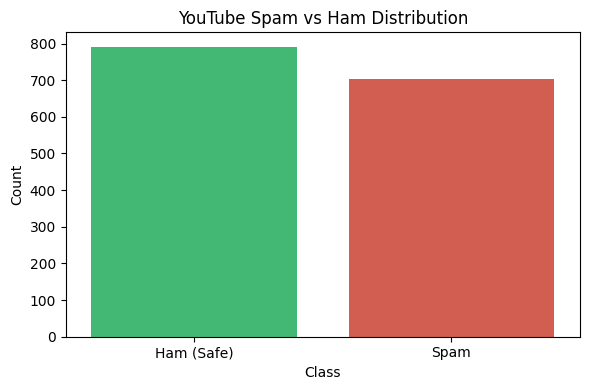

In [4]:
# Create Bar Chart
plt.figure(figsize=(6, 4))
sns.countplot(x='CLASS', data=df_yt, palette=['#2ecc71', '#e74c3c'], hue='CLASS', legend=False)
plt.title('YouTube Spam vs Ham Distribution')
plt.xticks([0, 1], ['Ham (Safe)', 'Spam'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()

# Save chart image for report
plt.savefig('/content/drive/MyDrive/youtube_class_distribution.png')
plt.show()

In [5]:
# Counts total 0s and 1s in the CLASS column
df_yt['CLASS'].value_counts()

,count
CLASS,
0,791
1,703


In [6]:
# Returns exact percentage distribution
df_yt['CLASS'].value_counts(normalize=True) * 100

,proportion
CLASS,
0,52.945114
1,47.054886


### YouTube Dataset EDA Results
| Item | Result |
| :--- | :--- |
| **Dataset Platform** | **YouTube Comments** |
| **Total Records (Rows)** | **1,494** |
| **Total Columns** | **5** (`COMMENT_ID`, `AUTHOR`, `DATE`, `CONTENT`, `CLASS`) |
| **Ham Count (Safe)** | **791** (52.9%) |
| **Spam Count** | **703** (47.1%) |
| **Missing Values** | **0** |
| **Duplicate Rows** | **1** |

In [7]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
# 1. Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [9]:
# Initialize Lemmatizer and Stopwords list
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [10]:
# Step-by-Step Preprocessing Function with Print Output
def preprocess_step_by_step(text):
    if not isinstance(text, str):
        return ""

    print("--------------------------------------------------------------------------------")
    print(" 0. Original Text       :", text)

    # Step 1: Replace URLs with [url] placeholder
    step1 = re.sub(r'http\S+|www\S+|https\S+|bit\.ly\S+|goo\.gl\S+', ' [url] ', text, flags=re.MULTILINE)
    print(" 1. Replace Links/URLs  :", step1)

    # Step 2: Lowercasing
    step2 = step1.lower()
    print(" 2. Lowercasing         :", step2)

    # Step 3: Remove Punctuation & Special Symbols (preserving [url])
    temp = step2.replace('[url]', 'URLTOKEN')
    temp = re.sub(r'[^a-z\s]', ' ', temp)
    step3 = temp.replace('urltoken', '[url]')
    print(" 3. Remove Special Chars:", step3)

    # Step 4: Tokenization & Stop Words Removal
    tokens = step3.split()
    step4 = [word for word in tokens if (word not in stop_words) or (word == '[url]')]
    print(" 4. Remove Stop Words   :", step4)

    # Step 5: Lemmatization
    step5 = [lemmatizer.lemmatize(word) for word in step4]
    print(" 5. Lemmatization (Final):", " ".join(step5))
    print("--------------------------------------------------------------------------------\n")

    return " ".join(step5)

In [11]:
# Load YouTube Excel Dataset
xls_yt = pd.ExcelFile('/content/drive/MyDrive/youtubeSpamCollection.xlsx')
df_yt_list = [pd.read_excel(xls_yt, sheet_name=s) for s in xls_yt.sheet_names]
df_yt = pd.concat(df_yt_list, ignore_index=True)

# Test the Step-by-Step output on first 3 comments
print("=== DEMO: STEP-BY-STEP PREPROCESSING OUTPUT ===\n")
for i in range(3):
    preprocess_step_by_step(df_yt['CONTENT'].iloc[i])

=== DEMO: STEP-BY-STEP PREPROCESSING OUTPUT ===

--------------------------------------------------------------------------------
 0. Original Text       : Huh, anyway check out this you[tube] channel: kobyoshi02
 1. Replace Links/URLs  : Huh, anyway check out this you[tube] channel: kobyoshi02
 2. Lowercasing         : huh, anyway check out this you[tube] channel: kobyoshi02
 3. Remove Special Chars: huh  anyway check out this you tube  channel  kobyoshi  
 4. Remove Stop Words   : ['huh', 'anyway', 'check', 'tube', 'channel', 'kobyoshi']
 5. Lemmatization (Final): huh anyway check tube channel kobyoshi
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
 0. Original Text       : Hey guys check out my new channel and our first vid THIS IS US THE  MONKEYS!!! I'm the monkey in the white shirt,please leave a like comment  and please subscribe!!!!
 1. Replace Links/URLs  : Hey gu

In [12]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Reload the original df_yt to ensure 'CONTENT' column is available
xls_yt = pd.ExcelFile('/content/drive/MyDrive/youtubeSpamCollection.xlsx')
df_yt_list = [pd.read_excel(xls_yt, sheet_name=s) for s in xls_yt.sheet_names]
df_yt = pd.concat(df_yt_list, ignore_index=True)

# Initialize Lemmatizer and Stopwords list (assuming these are defined in previous cells or here for completeness)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_youtube_comments(text):
    if not isinstance(text, str):
        return ""

    # Step 1: Replace URLs with 'urltoken' (Simple letters )
    step1 = re.sub(r'http\S+|www\S+|https\S+|bit\.ly\S+|goo\.gl\S+', ' urltoken ', text, flags=re.MULTILINE)

    # Step 2: Lowercasing
    step2 = step1.lower()

    # Step 3: Remove Punctuation & Special Symbols (urltoken remaining)
    step3 = re.sub(r'[^a-z\s]', ' ', step2)

    # Step 4: Tokenization & Stop Words Removal
    tokens = step3.split()
    step4 = [word for word in tokens if (word not in stop_words)]

    # Step 5: Lemmatization
    step5 = [lemmatizer.lemmatize(word) for word in step4]

    # Step 6: Reverting 'urltoken' back to '[url]
    final_words = ['[url]' if word == 'urltoken' else word for word in step5]

    return " ".join(final_words)


# 1. Apply preprocessing to the whole dataset
df_yt['cleaned_text'] = df_yt['CONTENT'].apply(preprocess_youtube_comments)

# 2. Prepare standard schema for Group Merging =
df_yt_prepared = df_yt[['cleaned_text', 'CLASS']].copy()
df_yt_prepared.columns = ['text', 'label']
df_yt_prepared['source'] = 'YouTube'

# 3. Save as CSV
df_yt_prepared.to_csv('/content/drive/MyDrive/youtube_cleaned.csv', index=False)
print("* Preprocessing Complete! 'youtube_cleaned.csv' saved successfully!")

* Preprocessing Complete! 'youtube_cleaned.csv' saved successfully!


In [13]:
import pandas as pd

# Load updated dataset
df_yt = pd.read_csv('/content/drive/MyDrive/youtube_cleaned.csv')

# 1. Remove remaining missing/null rows
df_yt_clean = df_yt.dropna(subset=['text']).reset_index(drop=True)
df_yt_clean = df_yt_clean[df_yt_clean['text'].str.strip() != ''].reset_index(drop=True)

# 2. Save final version
df_yt_clean.to_csv('/content/drive/MyDrive/youtube_cleaned_final.csv', index=False)

print(f"✅ Success! Total clean records: {len(df_yt_clean)}")
print(" 'youtube_cleaned_final.csv' is 100% ready for Task 5!")

✅ Success! Total clean records: 1482
 'youtube_cleaned_final.csv' is 100% ready for Task 5!


In [14]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/youtube_cleaned_final.csv')
print("Total Rows:", len(df))

Total Rows: 1482


In [15]:
import pandas as pd

# 1. Load all datasets from Google Drive
df_email = pd.read_csv('/content/drive/MyDrive/updated_cleaned_email_dataset.csv')
df_sms = pd.read_csv('/content/drive/MyDrive/cleaned_sms_dataset.csv')
df_yt = pd.read_csv('/content/drive/MyDrive/youtube_cleaned_final.csv')

# 2. Standardize Email Dataset
df_email_clean = pd.DataFrame()
df_email_clean['text'] = df_email['text']
df_email_clean['label'] = df_email['class']  # 1 = Spam, 0 = Ham
df_email_clean['source'] = 'Email'

# 3. Standardize SMS Dataset
df_sms_clean = pd.DataFrame()
df_sms_clean['text'] = df_sms['message']
df_sms_clean['label'] = df_sms['label'].map({'spam': 1, 'ham': 0})
df_sms_clean['source'] = 'SMS'

# 4. Standardize YouTube Dataset
df_yt_clean = df_yt[['text', 'label', 'source']].copy()

# 5. Combine all three datasets
df_combined = pd.concat([df_email_clean, df_sms_clean, df_yt_clean], ignore_index=True)

# 6. Ensure no missing or empty text values remaining
df_combined = df_combined.dropna(subset=['text']).reset_index(drop=True)
df_combined = df_combined[df_combined['text'].str.strip() != ''].reset_index(drop=True)

# 7. Save the final Combined Master Dataset to Google Drive
df_combined.to_csv('/content/drive/MyDrive/combined_spam_dataset.csv', index=False)

print("Combined and standardized datasets Completed Successfully!")
print(f"Total Combined Records: {len(df_combined)}")
print("\nBreakdown by Source:")
print(df_combined['source'].value_counts())
print("\nBreakdown by Label (1=Spam, 0=Ham):")
print(df_combined['label'].value_counts())

Combined and standardized datasets Completed Successfully!
Total Combined Records: 11818

Breakdown by Source:
source
SMS        5566
Email      4770
YouTube    1482
Name: count, dtype: int64

Breakdown by Label (1=Spam, 0=Ham):
label
0    8261
1    3557
Name: count, dtype: int64
